# TP1 — Insurance Charges

Objetivo: predecir `charges` y comparar regresión lineal y polinómica mediante validación cruzada. El conjunto de test se reserva antes del EDA usado para tomar decisiones. [P01, pp. 1–3]

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.10
DATA_PATH = Path('../../material/externo/datasets/insurance.csv')

sns.set_theme(style='whitegrid')

## 1. Carga y verificación de integridad

En esta etapa sólo verificamos identidad, esquema y legibilidad. Las distribuciones que influyan en decisiones se analizarán después de reservar test.

In [2]:
df = pd.read_csv(DATA_PATH)

expected_columns = [
    'age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'
]
assert df.shape == (1338, 7)
assert df.columns.tolist() == expected_columns

duplicate_mask = df.duplicated(keep='first')
assert duplicate_mask.sum() == 1
df_model = df.loc[~duplicate_mask].copy()
assert df_model.shape == (1337, 7)

df.info()
print(f'Duplicados exactos eliminados de la copia de trabajo: {duplicate_mask.sum()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
Duplicados exactos eliminados de la copia de trabajo: 1


## 2. Reserva de test

Antes de separar se elimina una de las dos filas exactamente duplicadas de la copia de trabajo. Conservar ambas permitiría que una aparezca en entrenamiento y otra en validación. El CSV original `[D01]` permanece intacto.

Se reserva el 10 % para la evaluación final. La estratificación por `smoker` es una propuesta operativa para conservar la proporción de esa categoría en ambos conjuntos; no utiliza `charges` para construir la partición.

In [3]:
X = df_model.drop(columns='charges')
y = df_model['charges']

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=X['smoker'],
)

assert len(X_dev) == len(y_dev) == 1203
assert len(X_test) == len(y_test) == 134
print(f'Desarrollo: {len(X_dev)}; test reservado: {len(X_test)}')

Desarrollo: 1203; test reservado: 134


## 3. EDA de desarrollo

A partir de aquí se trabaja con `X_dev` y `y_dev`. No se inspeccionan distribuciones ni resultados de test hasta seleccionar y reentrenar el pipeline final. [T02, pp. 94–96]

### 3.1 Tipos y controles de calidad

Se distinguen predictores numéricos, categóricos nominales y la variable objetivo. Se verifican faltantes, duplicados remanentes y categorías inesperadas. [P01, p. 2] [T02, p. 26]

In [4]:
numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']
target = 'charges'

dev = X_dev.copy()
dev[target] = y_dev

expected_categories = {
    'sex': {'female', 'male'},
    'smoker': {'no', 'yes'},
    'region': {'northeast', 'northwest', 'southeast', 'southwest'},
}

assert dev.isna().sum().sum() == 0
assert dev.duplicated().sum() == 0
for column, expected in expected_categories.items():
    assert set(dev[column].unique()) == expected

quality = pd.DataFrame({
    'tipo': dev.dtypes.astype(str),
    'faltantes': dev.isna().sum(),
    'valores_unicos': dev.nunique(),
})
display(quality)
print(f'Duplicados remanentes en desarrollo: {dev.duplicated().sum()}')

,tipo,faltantes,valores_unicos
age,int64,0,47
sex,object,0,2
bmi,float64,0,525
children,int64,0,6
smoker,object,0,2
region,object,0,4
charges,float64,0,1203


Duplicados remanentes en desarrollo: 0


### 3.2 Resumen y distribuciones

Los resúmenes numéricos y las frecuencias permiten detectar escalas, asimetrías y grupos poco representados.

In [5]:
display(dev[numeric_features + [target]].describe().T.round(2))

category_rows = []
for column in categorical_features:
    counts = dev[column].value_counts()
    for category, count in counts.items():
        category_rows.append({
            'variable': column,
            'categoria': category,
            'cantidad': count,
            'porcentaje': 100 * count / len(dev),
        })
category_summary = pd.DataFrame(category_rows)
display(category_summary.round({'porcentaje': 2}))

,count,mean,std,min,25%,50%,75%,max
age,1203.0,39.14,14.06,18.00,26.00,39.00,51.00,64.00
bmi,1203.0,30.72,6.12,15.96,26.36,30.50,34.80,53.13
children,1203.0,1.09,1.19,0.00,0.00,1.00,2.00,5.00
charges,1203.0,13350.56,12129.66,1121.87,4749.06,9447.25,17083.17,63770.43


,variable,categoria,cantidad,porcentaje
0,sex,male,615,51.12
1,sex,female,588,48.88
2,smoker,no,956,79.47
3,smoker,yes,247,20.53
4,region,southeast,328,27.27
5,region,southwest,293,24.36
6,region,northwest,291,24.19
7,region,northeast,291,24.19


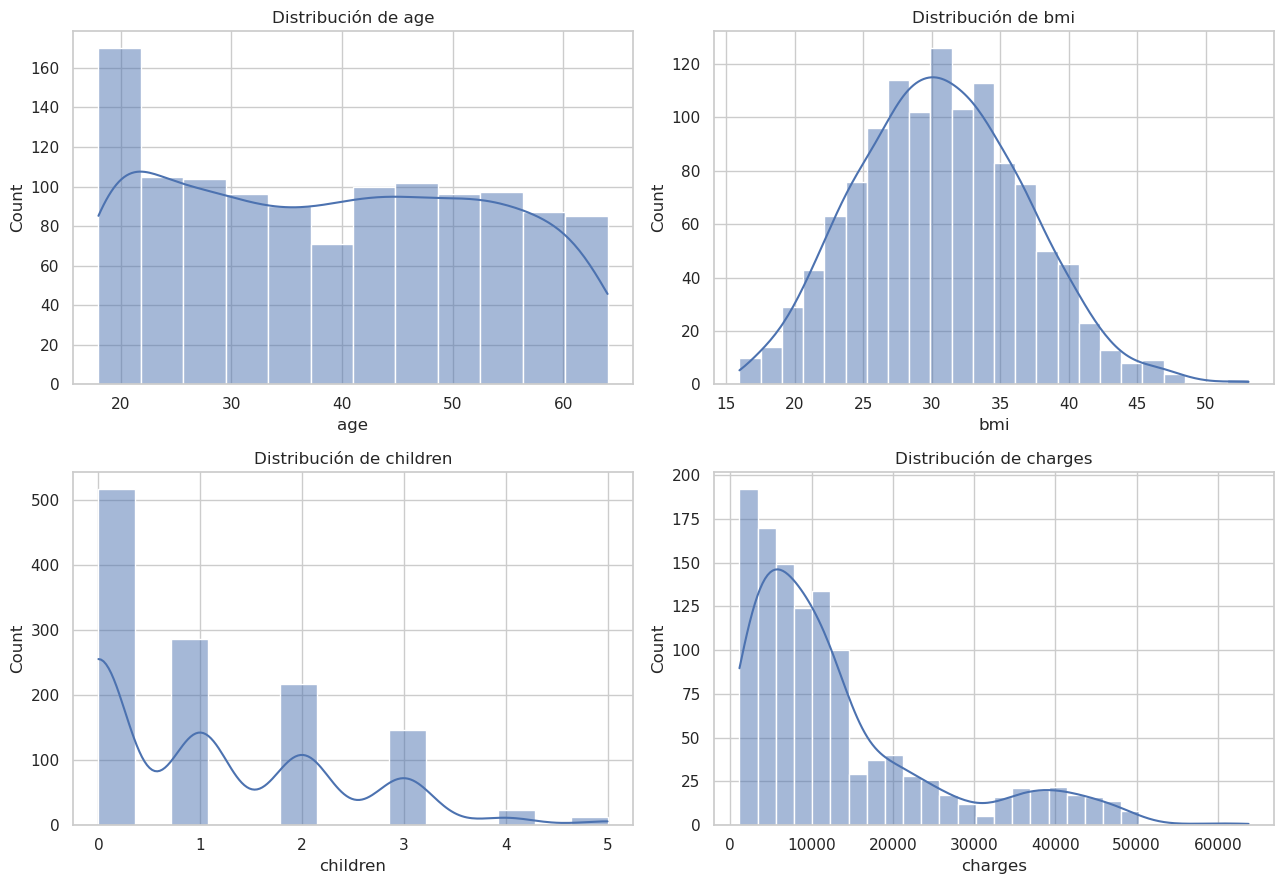

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for column, axis in zip(numeric_features + [target], axes.flat):
    sns.histplot(data=dev, x=column, kde=True, ax=axis)
    axis.set_title(f'Distribución de {column}')
plt.tight_layout()
plt.show()

### 3.3 Relación de los predictores con `charges`

Se examinan asociaciones, no relaciones causales. Una correlación lineal baja tampoco descarta una relación no lineal. [T03, pp. 48–51]

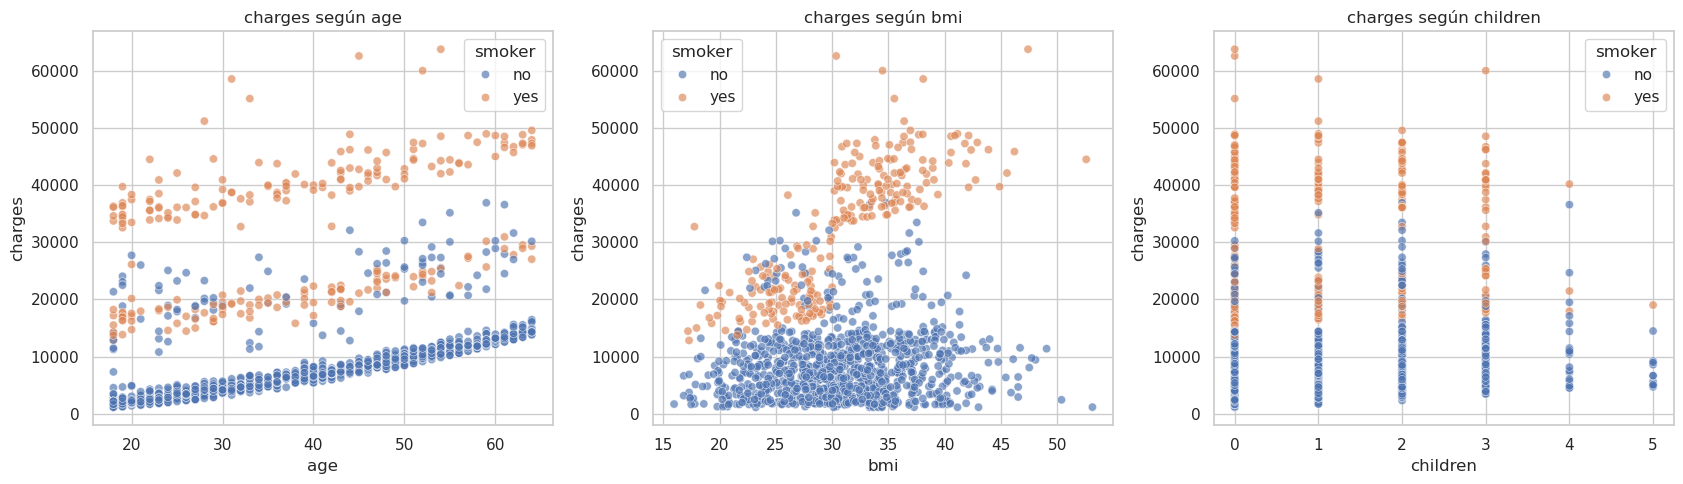

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for column, axis in zip(numeric_features, axes):
    sns.scatterplot(
        data=dev, x=column, y=target, hue='smoker', alpha=0.65, ax=axis
    )
    axis.set_title(f'{target} según {column}')
plt.tight_layout()
plt.show()

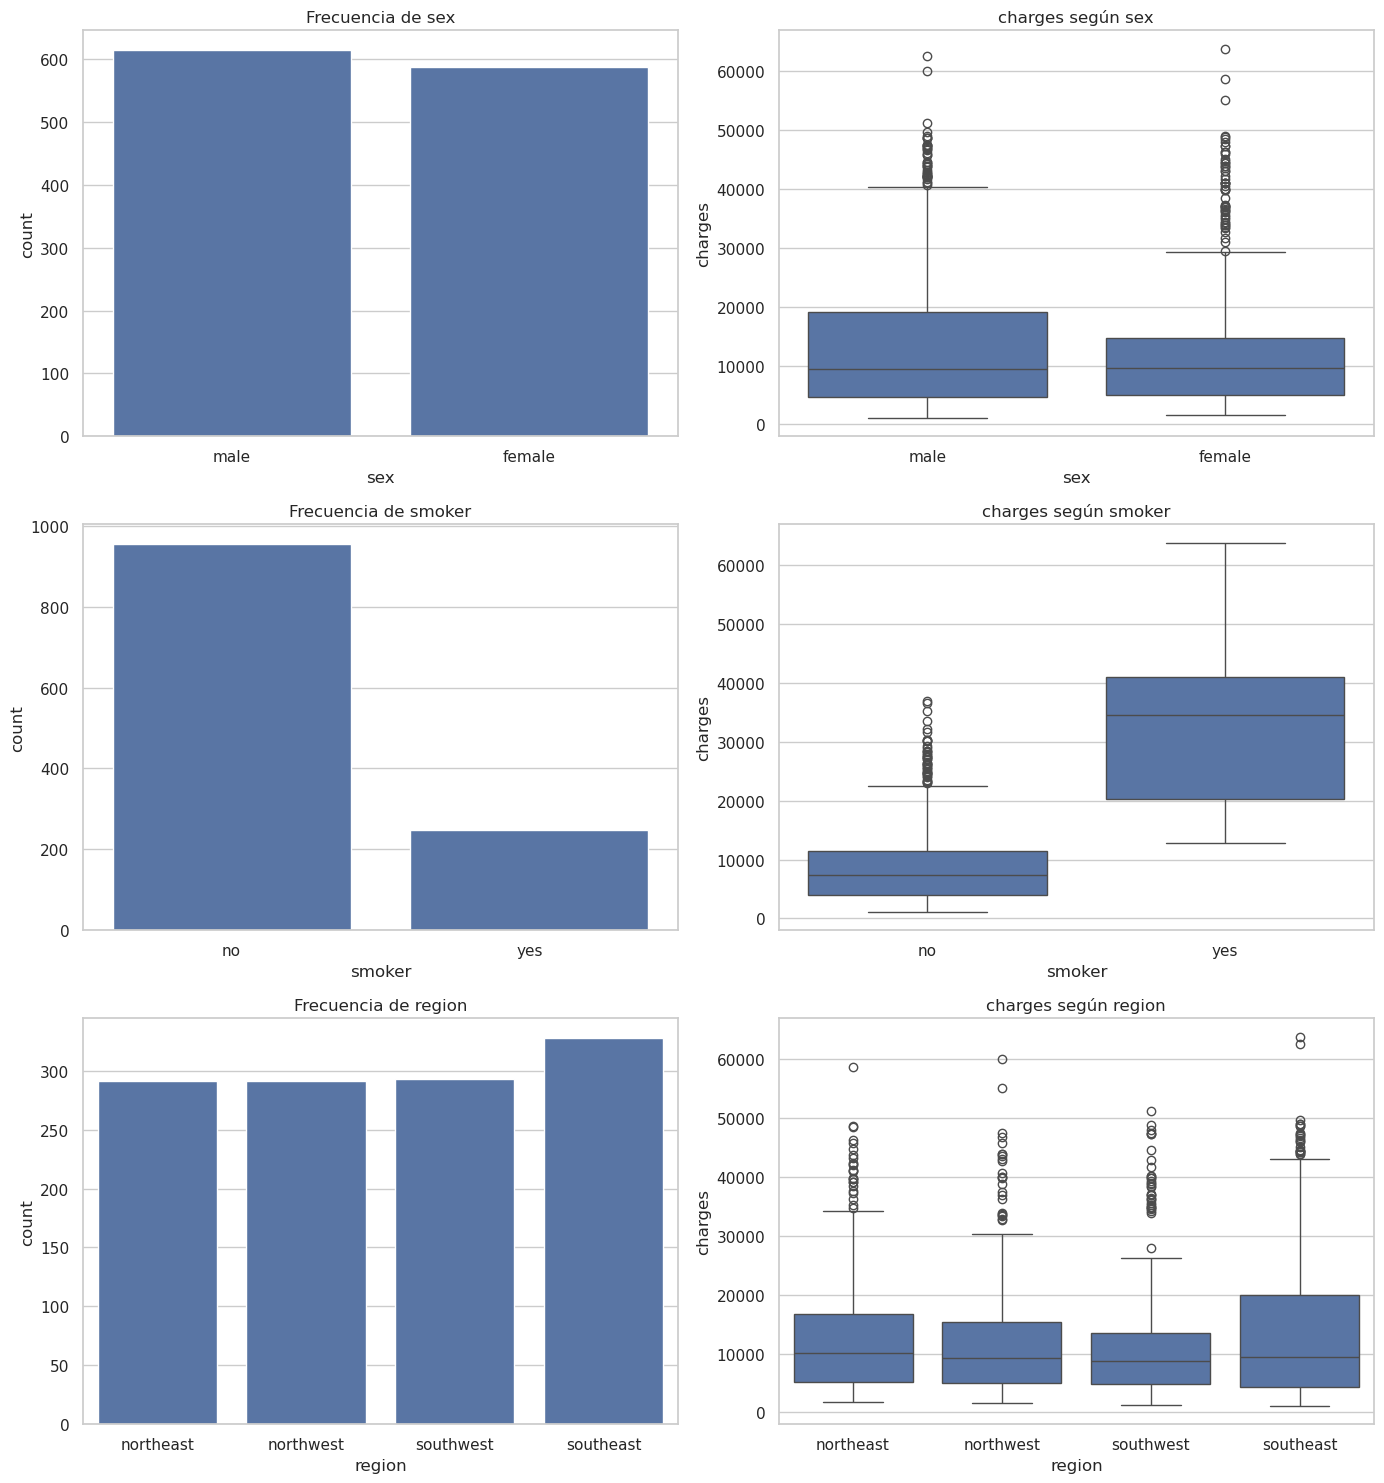

,variable,categoria,count,mean,median,std
0,sex,female,588,12705.65,9498.47,11163.97
1,sex,male,615,13967.16,9386.16,12965.12
2,smoker,no,956,8535.55,7331.40,6110.44
3,smoker,yes,247,31986.79,34472.84,11624.51
4,region,northeast,291,13489.33,10106.13,11307.41
5,region,northwest,291,12550.03,9174.14,11019.28
6,region,southeast,328,15041.71,9436.90,14250.27
7,region,southwest,293,12114.65,8703.46,11191.85


In [8]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
for row, column in enumerate(categorical_features):
    sns.countplot(data=dev, x=column, ax=axes[row, 0])
    axes[row, 0].set_title(f'Frecuencia de {column}')
    sns.boxplot(data=dev, x=column, y=target, ax=axes[row, 1])
    axes[row, 1].set_title(f'{target} según {column}')
plt.tight_layout()
plt.show()

group_rows = []
for column in categorical_features:
    summary = dev.groupby(column)[target].agg(['count', 'mean', 'median', 'std'])
    summary.insert(0, 'variable', column)
    summary.insert(1, 'categoria', summary.index)
    group_rows.append(summary.reset_index(drop=True))
categorical_target_summary = pd.concat(group_rows, ignore_index=True)
display(categorical_target_summary.round(2))

,age,bmi,children,charges
age,1.000,0.111,0.029,0.289
bmi,0.111,1.000,0.002,0.196
children,0.029,0.002,1.000,0.072
charges,0.289,0.196,0.072,1.000


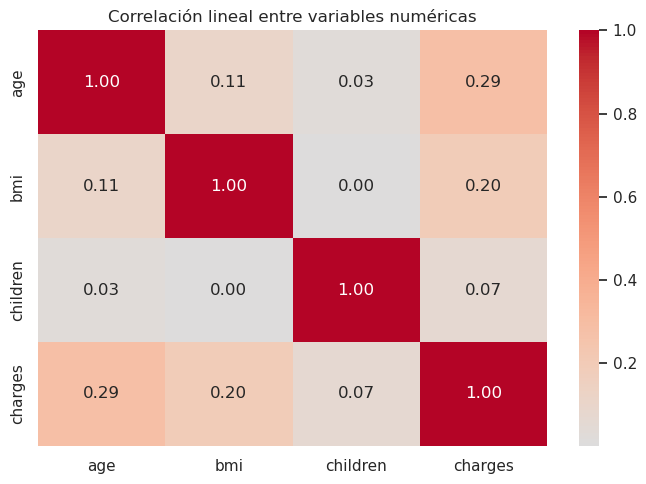

In [9]:
correlations = dev[numeric_features + [target]].corr(method='pearson')
display(correlations.round(3))

plt.figure(figsize=(7, 5))
sns.heatmap(correlations, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación lineal entre variables numéricas')
plt.tight_layout()
plt.show()

### 3.4 Detección de outliers con IQR

Se marca como atípico un valor fuera de `Q1 - 1.5·IQR` o `Q3 + 1.5·IQR`. La marca es una señal para investigar y no una orden automática de eliminación. [T02, pp. 39–42]

In [10]:
def iqr_report(data, columns):
    rows = []
    flags = pd.DataFrame(index=data.index)
    for column in columns:
        q1 = data[column].quantile(0.25)
        q3 = data[column].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        flag = (data[column] < lower) | (data[column] > upper)
        flags[column] = flag
        rows.append({
            'variable': column,
            'limite_inferior': lower,
            'limite_superior': upper,
            'cantidad_atipica': int(flag.sum()),
            'porcentaje_atipico': 100 * flag.mean(),
            'minimo': data[column].min(),
            'maximo': data[column].max(),
        })
    return pd.DataFrame(rows), flags

outlier_summary, outlier_flags = iqr_report(
    dev, numeric_features + [target]
)
display(outlier_summary.round(2))

print('Casos con BMI atípico:')
display(
    dev.loc[outlier_flags['bmi'], ['age', 'bmi', 'children', 'smoker', 'charges']]
    .sort_values('bmi')
    .round(2)
)

print('Valores atípicos de charges por condición de fumador:')
display(pd.crosstab(dev['smoker'], outlier_flags[target], margins=True))

,variable,limite_inferior,limite_superior,cantidad_atipica,porcentaje_atipico,minimo,maximo
0,age,-11.50,88.50,0,0.00,18.00,64.00
1,bmi,13.69,47.46,7,0.58,15.96,53.13
2,children,-3.00,5.00,0,0.00,0.00,5.00
3,charges,-13752.11,35584.34,118,9.81,1121.87,63770.43


Casos con BMI atípico:


,age,bmi,children,smoker,charges
401,47,47.52,1,no,8083.92
1088,52,47.74,1,no,9748.91
286,46,48.07,2,no,9432.93
116,58,49.06,0,no,11381.33
847,23,50.38,1,no,2438.06
1047,22,52.58,1,yes,44501.40
1317,18,53.13,0,no,1163.46


Valores atípicos de charges por condición de fumador:


charges,False,True,All
smoker,,,
no,954,2,956
yes,131,116,247
All,1085,118,1203


### 3.5 IQR condicionado por `smoker`

El IQR global puede mezclar subpoblaciones con distribuciones distintas. Para comprobarlo se recalculan cuartiles y límites dentro de fumadores y no fumadores. Los boxplots usan esa separación para cada variable numérica.

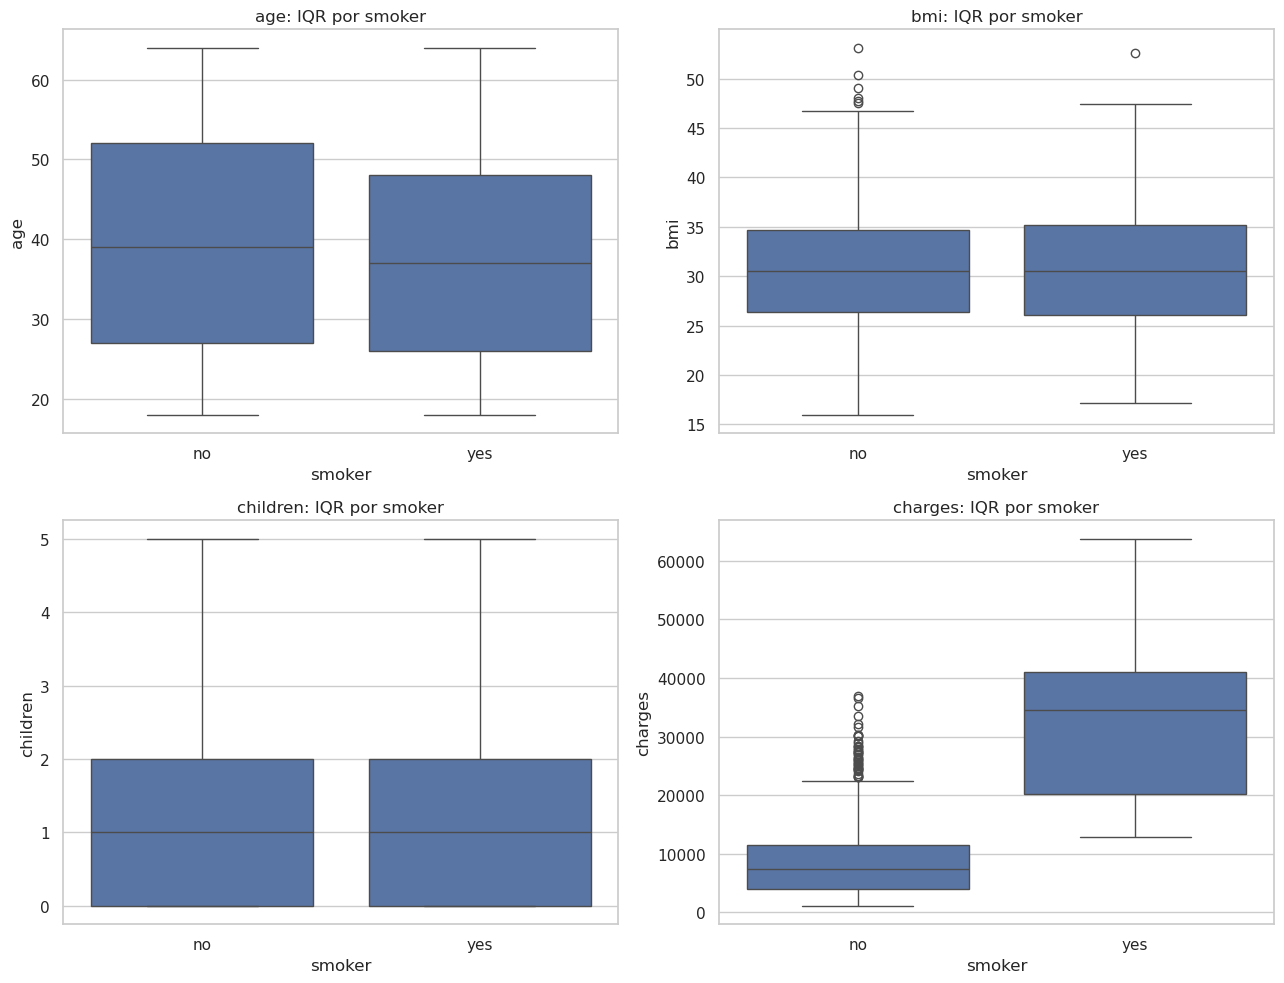

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for column, axis in zip(numeric_features + [target], axes.flat):
    sns.boxplot(data=dev, x='smoker', y=column, ax=axis)
    axis.set_title(f'{column}: IQR por smoker')
plt.tight_layout()
plt.show()

In [12]:
def grouped_iqr_report(data, group_column, columns):
    rows = []
    for group_value, group in data.groupby(group_column):
        for column in columns:
            q1 = group[column].quantile(0.25)
            q3 = group[column].quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            flag = (group[column] < lower) | (group[column] > upper)
            rows.append({
                group_column: group_value,
                'variable': column,
                'n_grupo': len(group),
                'q1': q1,
                'q3': q3,
                'iqr': iqr,
                'limite_inferior': lower,
                'limite_superior': upper,
                'cantidad_atipica': int(flag.sum()),
                'porcentaje_atipico': 100 * flag.mean(),
            })
    return pd.DataFrame(rows)

grouped_outlier_summary = grouped_iqr_report(
    dev, 'smoker', numeric_features + [target]
)
display(grouped_outlier_summary.round(2))

,smoker,variable,n_grupo,q1,q3,iqr,limite_inferior,limite_superior,cantidad_atipica,porcentaje_atipico
0,no,age,956,27.00,52.00,25.00,-10.50,89.50,0,0.00
1,no,bmi,956,26.40,34.68,8.28,13.98,47.10,6,0.63
2,no,children,956,0.00,2.00,2.00,-3.00,5.00,0,0.00
3,no,charges,956,4002.61,11454.34,7451.72,-7174.98,22631.92,43,4.50
4,yes,age,247,26.00,48.00,22.00,-7.00,81.00,0,0.00
5,yes,bmi,247,26.10,35.20,9.10,12.44,48.85,1,0.40
6,yes,children,247,0.00,2.00,2.00,-3.00,5.00,0,0.00
7,yes,charges,247,20265.86,41065.69,20799.83,-10933.89,72265.44,0,0.00


### 3.6 Decisiones derivadas del EDA

**Calidad.** Desarrollo no contiene faltantes, duplicados remanentes ni categorías inesperadas. Por lo tanto, no hace falta imputar valores.

**Distribuciones y relaciones.** `charges` presenta asimetría positiva: su media es 13.350,56, la mediana 9.447,25 y el máximo 63.770,43. `smoker` separa grupos especialmente distintos: la media de `charges` es 31.986,79 para fumadores y 8.535,55 para no fumadores. Las correlaciones lineales de `charges` con `age`, `bmi` y `children` son 0,289, 0,196 y 0,072; estos valores no descartan interacciones ni relaciones no lineales.

**Outliers.** IQR global no marca casos en `age` ni `children`; marca 7 BMI altos (0,58 %) y 118 valores altos de `charges` (9,81 %). Al recalcular dentro de cada grupo, se mantienen 6 BMI altos entre no fumadores y 1 entre fumadores. En `charges`, ningún fumador resulta atípico respecto de la distribución de fumadores; aparecen 43 costos altos entre no fumadores, por encima de 22.631,92. Esto confirma que el IQR global confundía principalmente la diferencia entre subpoblaciones con casos anómalos. La propuesta sigue siendo conservarlos: no hay evidencia de errores de carga y eliminar esos costos cambiaría la población que se quiere predecir. [T02, pp. 39–42]

**Características.** Se propone conservar inicialmente las seis. `sex` y `region` muestran diferencias univariadas pequeñas, pero el dataset tiene baja dimensionalidad y descartarlas ahora podría ocultar interacciones que compararemos mediante validación.

**Preprocesamiento.** Las variables categóricas son nominales y se codifican con one-hot. Las numéricas tienen escalas distintas y se estandarizan, especialmente porque se evaluarán términos polinómicos y regularización L1. Los transformadores que aprendan parámetros se ajustan dentro de cada fold. [T02, p. 18] [T03, pp. 40–43] [T02, pp. 94–96]

## 4. Regresión lineal con validación cruzada

Se usa 10-fold cross-validation sobre desarrollo. Los folds se estratifican por `smoker` para evitar que diferencias accidentales en la proporción de fumadores dominen el RMSE. Cada observación participa exactamente una vez en validación. [P01, p. 2] [T03, pp. 12, 15]

In [13]:
N_SPLITS = 10
cv_splitter = StratifiedKFold(
    n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE
)
cv_splits = list(cv_splitter.split(X_dev, X_dev['smoker']))

validation_positions = sorted(
    position for _, validation_idx in cv_splits for position in validation_idx
)
assert validation_positions == list(range(len(X_dev)))

fold_composition = pd.DataFrame([
    {
        'fold': fold,
        'n_train': len(train_idx),
        'n_validation': len(validation_idx),
        'fumadores_train': int((X_dev.iloc[train_idx]['smoker'] == 'yes').sum()),
        'fumadores_validation': int(
            (X_dev.iloc[validation_idx]['smoker'] == 'yes').sum()
        ),
    }
    for fold, (train_idx, validation_idx) in enumerate(cv_splits, start=1)
])
display(fold_composition)

,fold,n_train,n_validation,fumadores_train,fumadores_validation
0,1,1082,121,222,25
1,2,1082,121,222,25
2,3,1082,121,222,25
3,4,1083,120,223,24
4,5,1083,120,223,24
5,6,1083,120,223,24
6,7,1083,120,222,25
7,8,1083,120,222,25
8,9,1083,120,222,25
9,10,1083,120,222,25


### 4.1 Pipeline de preprocesamiento

`age`, `bmi` y `children` se estandarizan. `sex`, `smoker` y `region` usan one-hot, eliminando una categoría de referencia para evitar columnas redundantes con el intercepto. Al estar dentro de `Pipeline`, cada transformador se ajusta sólo con el entrenamiento del fold.

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(), numeric_features),
        (
            'categorical',
            OneHotEncoder(drop='first', handle_unknown='ignore'),
            categorical_features,
        ),
    ]
)

linear_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LinearRegression()),
])

linear_pipeline

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 4.2 RMSE de train y validación

Como control se incluye un predictor ingenuo que siempre usa la media aprendida en el entrenamiento del fold. La métrica es RMSE, en las mismas unidades que `charges`. [T03, p. 87]

In [15]:
def cross_validated_rmse(model, model_name):
    scores = cross_validate(
        model,
        X_dev,
        y_dev,
        cv=cv_splits,
        scoring='neg_root_mean_squared_error',
        return_train_score=True,
    )
    return pd.DataFrame({
        'modelo': model_name,
        'fold': range(1, N_SPLITS + 1),
        'rmse_train': -scores['train_score'],
        'rmse_validation': -scores['test_score'],
    })

dummy_fold_metrics = cross_validated_rmse(
    DummyRegressor(strategy='mean'), 'Referencia: media'
)
linear_fold_metrics = cross_validated_rmse(
    linear_pipeline, 'Regresión lineal'
)
all_fold_metrics = pd.concat(
    [dummy_fold_metrics, linear_fold_metrics], ignore_index=True
)

display(linear_fold_metrics.round(2))

model_summary = pd.DataFrame([
    {
        'modelo': model_name,
        'rmse_train_media': metrics['rmse_train'].mean(),
        'rmse_train_std': metrics['rmse_train'].std(ddof=1),
        'rmse_validation_media': metrics['rmse_validation'].mean(),
        'rmse_validation_std': metrics['rmse_validation'].std(ddof=1),
    }
    for model_name, metrics in all_fold_metrics.groupby('modelo', sort=False)
])
display(model_summary.round(2))

,modelo,fold,rmse_train,rmse_validation
0,Regresión lineal,1,6096.79,6557.50
1,Regresión lineal,2,6037.45,6989.86
2,Regresión lineal,3,6116.67,6367.41
3,Regresión lineal,4,6090.02,6577.76
4,Regresión lineal,5,6235.34,5199.05
5,Regresión lineal,6,6069.45,6745.84
6,Regresión lineal,7,6201.56,5539.04
7,Regresión lineal,8,6185.44,5696.21
8,Regresión lineal,9,6186.78,5679.53
9,Regresión lineal,10,6130.88,6223.48


,modelo,rmse_train_media,rmse_train_std,rmse_validation_media,rmse_validation_std
0,Referencia: media,12124.07,100.62,12096.21,881.00
1,Regresión lineal,6135.04,64.44,6157.57,593.14


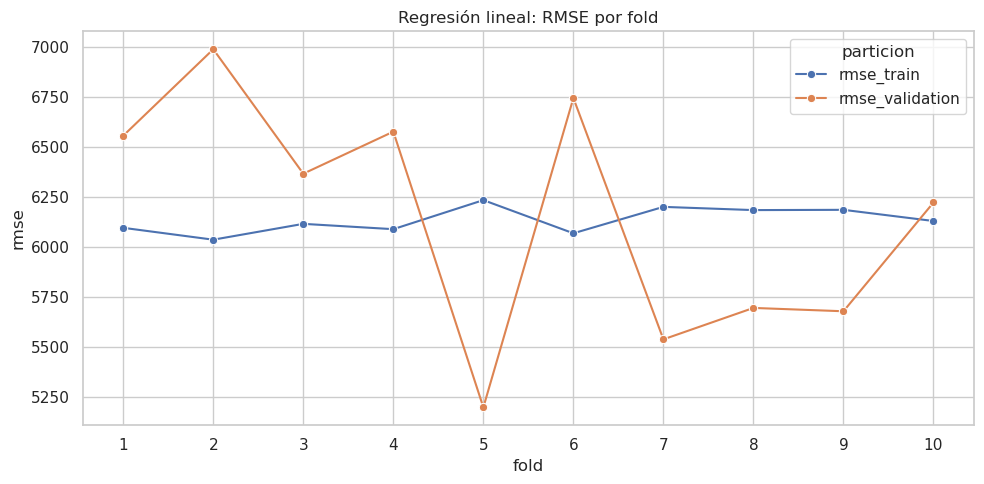

In [16]:
linear_long = linear_fold_metrics.melt(
    id_vars='fold',
    value_vars=['rmse_train', 'rmse_validation'],
    var_name='particion',
    value_name='rmse',
)
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=linear_long, x='fold', y='rmse', hue='particion', marker='o'
)
plt.xticks(range(1, N_SPLITS + 1))
plt.title('Regresión lineal: RMSE por fold')
plt.tight_layout()
plt.show()

### 4.3 Resultado del modelo lineal

La regresión lineal obtiene RMSE medio de **6.135,04 en train** y **6.157,57 en validación** (desvío entre folds: 593,14). La referencia que predice la media obtiene 12.096,21 en validación, por lo que el modelo lineal reduce el error aproximadamente 49 %.

La cercanía entre train y validación no muestra una brecha importante de overfitting para este modelo. Sin embargo, el EDA mostró bandas e interacciones asociadas a `smoker`, `age` y `bmi` que una combinación lineal aditiva no puede representar; esto motiva comparar grados polinómicos. Test continúa reservado.

## 5. Regresión polinómica

Se comparan grados 2 y 3 con la regresión lineal (grado 1), usando exactamente los mismos folds. `PolynomialFeatures` agrega potencias e interacciones sobre las ocho columnas preprocesadas; por ejemplo, `age²`, `bmi²`, `age·bmi` y `bmi·smoker`. El modelo que se entrena sobre esas columnas sigue siendo una regresión lineal en sus coeficientes. [P01, p. 2] [T02, p. 52]

In [17]:
POLYNOMIAL_DEGREES = [2, 3]
polynomial_pipelines = {}
polynomial_fold_metrics = []
complexity_rows = [
    {'grado': 1, 'terminos_generados': 8},
]

for degree in POLYNOMIAL_DEGREES:
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        (
            'polynomial',
            PolynomialFeatures(degree=degree, include_bias=False),
        ),
        ('model', LinearRegression()),
    ])
    polynomial_pipelines[degree] = pipeline

    metrics = cross_validated_rmse(
        pipeline, f'Polinómica grado {degree}'
    )
    metrics['grado'] = degree
    polynomial_fold_metrics.append(metrics)

    polynomial_counter = PolynomialFeatures(
        degree=degree, include_bias=False
    ).fit([[0] * 8])
    complexity_rows.append({
        'grado': degree,
        'terminos_generados': polynomial_counter.n_output_features_,
    })

polynomial_fold_metrics = pd.concat(
    polynomial_fold_metrics, ignore_index=True
)
complexity_table = pd.DataFrame(complexity_rows)
display(complexity_table)

,grado,terminos_generados
0,1,8
1,2,44
2,3,164


La cantidad de columnas aumenta de 8 a 44 y 164. Algunas potencias de indicadores one-hot son redundantes, por lo que esta cifra describe términos generados y no grados de libertad independientes. El solucionador de mínimos cuadrados puede trabajar con esa redundancia, pero la complejidad creciente puede aumentar la varianza.

In [18]:
linear_for_comparison = linear_fold_metrics.copy()
linear_for_comparison['grado'] = 1
complexity_fold_metrics = pd.concat(
    [linear_for_comparison, polynomial_fold_metrics], ignore_index=True
)

complexity_summary = pd.DataFrame([
    {
        'grado': int(degree),
        'rmse_train_media': metrics['rmse_train'].mean(),
        'rmse_train_std': metrics['rmse_train'].std(ddof=1),
        'rmse_validation_media': metrics['rmse_validation'].mean(),
        'rmse_validation_std': metrics['rmse_validation'].std(ddof=1),
        'brecha_validation_train': (
            metrics['rmse_validation'].mean()
            - metrics['rmse_train'].mean()
        ),
    }
    for degree, metrics in complexity_fold_metrics.groupby('grado')
])
display(complexity_summary.round(2))

,grado,rmse_train_media,rmse_train_std,rmse_validation_media,rmse_validation_std,brecha_validation_train
0,1,6135.04,64.44,6157.57,593.14,22.53
1,2,4795.02,80.15,4908.79,754.16,113.77
2,3,4609.56,79.58,5040.02,763.90,430.46


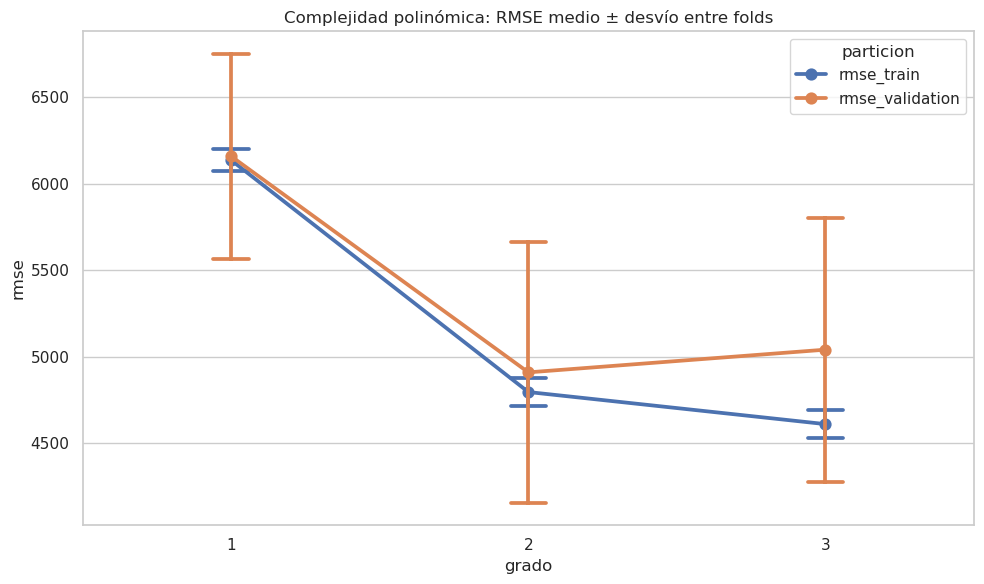

In [19]:
complexity_long = complexity_fold_metrics.melt(
    id_vars=['fold', 'grado'],
    value_vars=['rmse_train', 'rmse_validation'],
    var_name='particion',
    value_name='rmse',
)
plt.figure(figsize=(10, 6))
sns.pointplot(
    data=complexity_long,
    x='grado',
    y='rmse',
    hue='particion',
    errorbar='sd',
    capsize=0.12,
)
plt.title('Complejidad polinómica: RMSE medio ± desvío entre folds')
plt.tight_layout()
plt.show()

### 5.1 Comparación por grado

El **grado 2** obtiene el menor RMSE de validación: **4.908,79 ± 754,16**, frente a 6.157,57 del grado 1. Su RMSE de train es 4.795,02 y la brecha media train-validación es 113,77.

El **grado 3** reduce train a 4.609,56, pero validación sube a **5.040,02 ± 763,90** y la brecha crece a 430,46. Es una señal de que el aumento de complejidad empieza a ajustar peculiaridades de train sin mejorar la generalización. Por validación, grado 2 es el candidato actual. Test no fue consultado.